# 06_symbolic_forecasting.ipynb
This notebook builds a symbolic polynomial forecasting model using SageMath. You can experiment with:
- Degree of the polynomial
- Number of training samples
- Prediction horizon
- Evaluation accuracy


## 1. Setup and Data Load

In [12]:
from sage.all import *
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
import numpy as np
df = pd.read_csv('../data/bitcoin_timeseries.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').set_index('timestamp')

## 2. Define Hyperparameters

In [13]:
days_to_use = 7
resample_freq = '1h'
samples_to_use = 100
degree = 5
forecast_hours = 12

## 3. Prepare Training Data

In [14]:
# Get last timestamp and build mask manually
last_timestamp = df.index.max()
recent = df.loc[df.index >= last_timestamp - pd.Timedelta(days=int(14))] 

# Resample to hourly, drop missing, reset index
df_model = recent.resample('1h').mean().dropna().reset_index()

# Use only last 100 data points for stability
df_model = df_model.tail(int(100))

# Normalize time: convert to hours, then center around mean
timestamps = df_model['timestamp']
x_vals = [(t - timestamps.iloc[int(0)]).total_seconds() / int(3600) for t in timestamps]
x_mean = sum(x_vals) / len(x_vals)
x_vals = [x - x_mean for x in x_vals]

# Get y-values
y_vals = list(df_model['price_usd'])

print(f"✅ Using {len(x_vals)} normalized points from last 14 days")


✅ Using 100 normalized points from last 14 days


## 4. Symbolic Polynomial Fitting

In [15]:
x = var('x')
params = list(var([f'a{i}' for i in range(degree + 1)]))
model = sum(params[i] * x**i for i in range(degree + 1))
points = list(zip(x_vals, y_vals))
fit = find_fit(points, model, parameters=params, variables=[x], solution_dict=True)
model_fitted = model.subs(fit)
f = lambda t: float(model_fitted.subs(x=t))
y_fit = [f(t) for t in x_vals]

## 5. Forecast Future Values

In [16]:
last_x = float(x_vals[-1])
future_x = [last_x + float(i) for i in range(1, forecast_hours + 1)]
future_preds = [f(t) for t in future_x]
timestamps_list = list(df_model['timestamp'])
last_time = timestamps_list[-1]
future_times = [last_time + timedelta(hours=i) for i in range(1, forecast_hours + 1)]
df_future = pd.DataFrame({
    'timestamp': future_times,
    'predicted_price': future_preds
})

## 6. Plot Historical and Forecasted Values

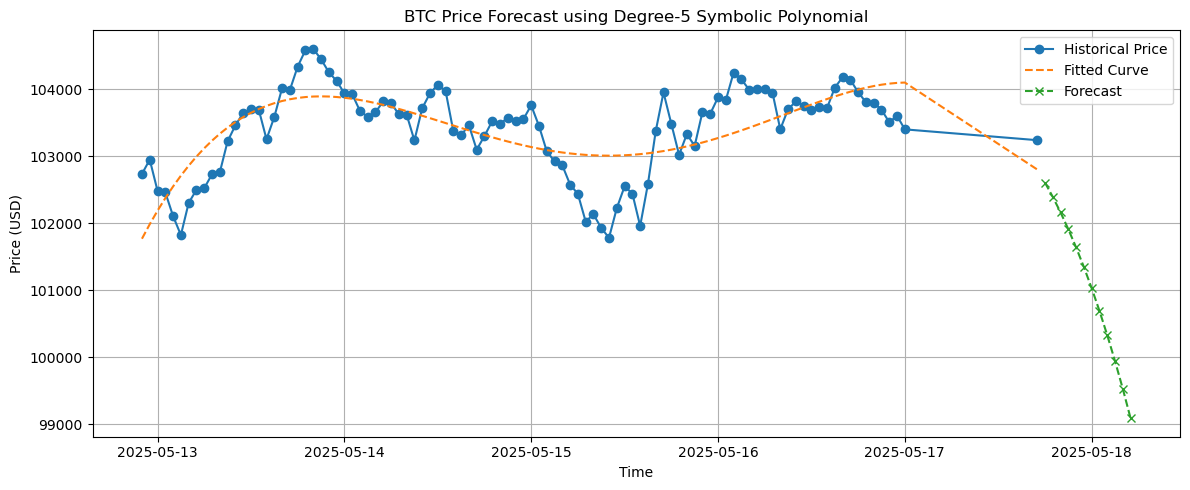

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(df_model['timestamp'], y_vals, label='Historical Price', marker='o')
plt.plot(df_model['timestamp'], y_fit, label='Fitted Curve', linestyle='--')
plt.plot(df_future['timestamp'], df_future['predicted_price'], label='Forecast', marker='x', linestyle='--')
plt.title(f"BTC Price Forecast using Degree-{degree} Symbolic Polynomial")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('../reports/symbolic_forecast_polydeg{}.png'.format(degree))
plt.show()

## 7. Evaluate Fit Accuracy on Training Data

In [18]:
try:
    from sklearn.metrics import mean_absolute_error, mean_squared_error

    # Ensure values are plain Python floats
    y_vals_py = [float(y) for y in y_vals]
    y_fit_py = [float(y) for y in y_fit]

    # Compute MAE and RMSE
    mae = mean_absolute_error(y_vals_py, y_fit_py)
    rmse = (mean_squared_error(y_vals_py, y_fit_py)) ** 0.5  # compatible with older sklearn

    print(f"📏 MAE (Mean Absolute Error): {mae:.2f} USD")
    print(f"📏 RMSE (Root Mean Squared Error): {rmse:.2f} USD")

except ImportError:
    # Manual fallback if sklearn is not installed
    y_vals_py = [float(y) for y in y_vals]
    y_fit_py = [float(y) for y in y_fit]

    mae = sum(abs(y_true - y_pred) for y_true, y_pred in zip(y_vals_py, y_fit_py)) / len(y_vals_py)
    rmse = (sum((y_true - y_pred)**2 for y_true, y_pred in zip(y_vals_py, y_fit_py)) / len(y_vals_py))**0.5

    print(f"📏 MAE (Mean Absolute Error): {mae:.2f} USD")
    print(f"📏 RMSE (Root Mean Squared Error): {rmse:.2f} USD")


📏 MAE (Mean Absolute Error): 375.23 USD
📏 RMSE (Root Mean Squared Error): 472.94 USD


## 8. Print Symbolic Expression

In [19]:
print("\nPolynomial Expression:")
print(model_fitted)
print("\nCoefficients:")
for i in range(degree + 1):
    coef = fit.get(var(f'a{i}'), 0)
    print(f"  a{i} = {coef}")


Polynomial Expression:
-(9.903193248430187e-07)*x^5 - 0.0004338502252459048*x^4 + 0.02222455438382276*x^3 + 0.9838184243998995*x^2 - 25.336895839916508*x + 103142.98166918395

Coefficients:
  a0 = 103142.98166918395
  a1 = -25.336895839916508
  a2 = 0.9838184243998995
  a3 = 0.02222455438382276
  a4 = -0.0004338502252459048
  a5 = -9.903193248430187e-07


In [20]:
df_symbolic = pd.DataFrame({
    'timestamp': df_model['timestamp'].tolist() + df_future['timestamp'].tolist(),
    'actual': y_vals + [None] * len(df_future),
    'symbolic_pred': list(y_fit) + df_future['predicted_price'].tolist()
})
df_symbolic.to_csv('../reports/symbolic_forecast.csv', index=False)

In [21]:
with open('../reports/symbolic_metrics.txt', 'w') as f:
    f.write(f"MAE: {mae:.2f}\n")
    f.write(f"RMSE: {rmse:.2f}\n")